# Linear Bivariate BMM with SAMBA toy models : switchcos mixing - bilby constrained priors

The best way to learn Taweret is to use it. You can run, modify and experiment with this notebook on [GitHub Codespaces](https://github.com/bandframework/Taweret).

This notebook shows how to use the Bayesian model mixing package **Taweret** for a toy problem. 

Author : Dan Liyanage 

Date : 11/10/2022

More about SAMBA toy models can be found in [Uncertainties here, there, and everywhere: interpolating between small- and large-g expansions using Bayesian Model Mixing](https://arxiv.org/abs/2206.04116)



**Steps for Bayesian Model Mixing with Taweret**

    1. Define your models using BaseModel class in `Taweret.core.base_model` (Only if you want to bring in your own models)
    2. Choose a Mixing method (Avilable mixing methods can be found in Taweret/mix)
    3. Find the posterior for the mixture weights (parameters in the mixture function) and/or model parameters by training the mixed model. 
    4. Make predictions! 

In [1]:
import sys
import os

# You will have to change the following imports depending on where you have 
# the packages installed

# ! pip install Taweret    # if using Colab, uncomment to install

cwd = os.getcwd()

# Get the first part of this path and append to the sys.path
tw_path = cwd.split("Taweret/")[0] + "Taweret"
sys.path.append(tw_path)

# For plotting
import matplotlib.pyplot as plt

! pip install seaborn    # comment if installed
! pip install ptemcee    # comment if installed

import seaborn as sns
sns.set_context('poster')
# To define priors. (uncomment if not using default priors)
# ! pip install bilby     # uncomment if not already installed
import bilby

# For other operations
import numpy as np

## 1. Get toy models and the pseudo-experimental data

In [2]:
# Toy models from SAMBA
from Taweret.models import samba_models as toy_models

m1 = toy_models.Loworder(2, 'uninformative')
m2 = toy_models.Highorder(2, 'uninformative')
truth = toy_models.TrueModel()
exp = toy_models.Data()

In [3]:
g = np.linspace(0.1, 0.6, 10)
plot_g = np.linspace(0.01,1,100)
m1_prediction = m1.evaluate(plot_g)
m2_prediction = m2.evaluate(plot_g)
true_output = truth.evaluate(plot_g)
exp_data= exp.evaluate(g,error = 0.01)

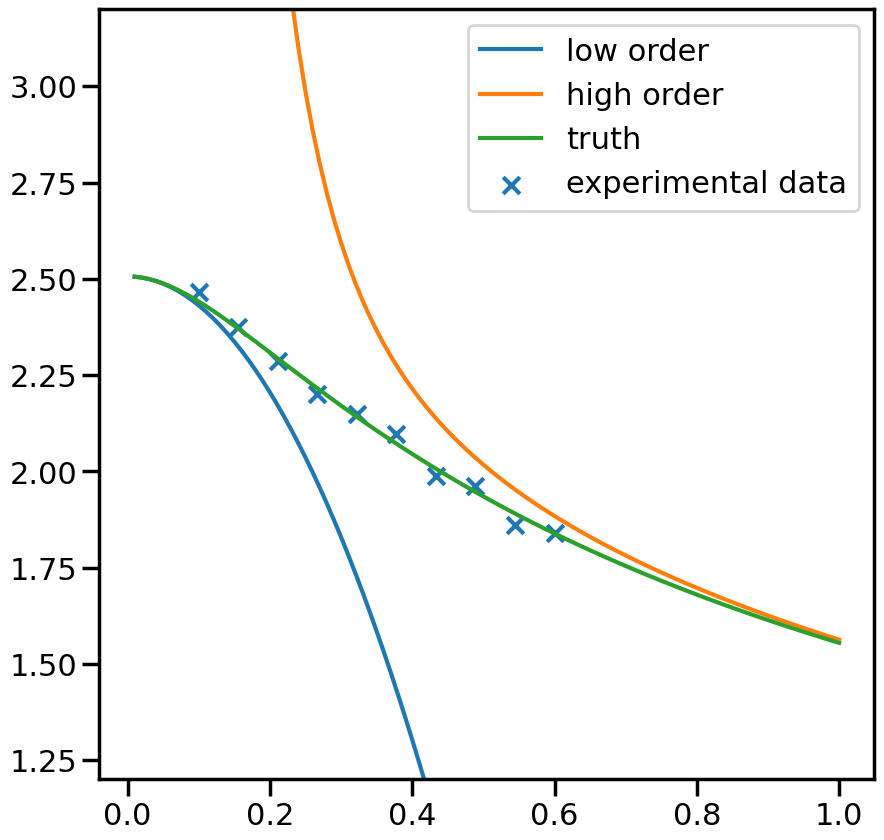

In [4]:

fig, ax_f = plt.subplots(figsize=(10,10))
ax_f.plot(plot_g, m1_prediction[0].flatten(), label='low order')
ax_f.plot(plot_g, m2_prediction[0].flatten(), label='high order')
ax_f.plot(plot_g, true_output[0], label='truth')
ax_f.scatter(g,exp_data[0], marker='x', label='experimental data')
ax_f.set_ylim(1.2,3.2)
ax_f.legend()

##  2. Choose a Mixing method

In [5]:
# Mixing method
from Taweret.mix.bivariate_linear import BivariateLinear as BL

models= {'low_order':m1,'high_order':m2}
mix_model = BL(models_dic=models, method='switchcos') 

switchcos mixing function has 3                   free parameter(s)
To change the prior use `set_prior` method


Need to speceify a constained prior for switchcos. g1 < g3 < g2

We follow Bilby documentation on how to specefy a prior with constraints
https://lscsoft.docs.ligo.org/bilby/prior.html#prior-constraints

In [30]:
#uncoment to change the prior from the default
def convert_x_y_to_z(parameters):
    """
    Function to convert between sampled parameters and constraint parameter.

    Parameters
    ----------
    parameters: dict
        Dictionary containing sampled parameter values, 'theta_0', 'theta_1', 'theta_2'.

    Returns
    -------
    dict: Dictionary with constraint parameter 'z_0, z_1' added.
    """
    converted_parameters = parameters.copy()
    converted_parameters['z_0'] = parameters['switchcos_2'] - parameters['switchcos_0']
    converted_parameters['z_1'] = parameters['switchcos_1'] - parameters['switchcos_2']
    return converted_parameters

from bilby.core.prior import PriorDict, Uniform, Constraint, TruncatedNormal

priors = PriorDict(conversion_function=convert_x_y_to_z)

priors['switchcos_0'] = TruncatedNormal(0.1, 0.05, 0.01, 0.3)
priors['switchcos_1'] = TruncatedNormal(0.6, 0.05, 0, 0.8)
priors['switchcos_2'] = TruncatedNormal(0.4, 0.05, 0, 0.55)

def z_constraint(params):
    z0 = params['switchcos_2'] - params['switchcos_0']
    z1 = params['switchcos_1'] - params['switchcos_2']
    if not (params['switchcos_0'] > params['switchcos_2'] > params['switchcos_1']):
        return False
    if not (0 < z0 < 1 and 0 < z1 < 1):
        return False
    return True

priors['z_0'] = Constraint(minimum=0, maximum=1)
priors['z_1'] = Constraint(minimum=0, maximum=1)
mix_model.set_prior(priors)

{'switchcos_0': TruncatedNormal(mu=0.1, sigma=0.05, minimum=0.01, maximum=0.3, name=None, latex_label=None, unit=None, boundary=None),
 'switchcos_1': TruncatedNormal(mu=0.6, sigma=0.05, minimum=0, maximum=0.8, name=None, latex_label=None, unit=None, boundary=None),
 'switchcos_2': TruncatedNormal(mu=0.4, sigma=0.05, minimum=0, maximum=0.55, name=None, latex_label=None, unit=None, boundary=None),
 'z_0': Constraint(minimum=0, maximum=1, name=None, latex_label=None, unit=None),
 'z_1': Constraint(minimum=0, maximum=1, name=None, latex_label=None, unit=None)}

## 3. Train to find posterior

In [31]:
mix_model.prior

{'switchcos_0': TruncatedNormal(mu=0.1, sigma=0.05, minimum=0.01, maximum=0.3, name=None, latex_label=None, unit=None, boundary=None),
 'switchcos_1': TruncatedNormal(mu=0.6, sigma=0.05, minimum=0, maximum=0.8, name=None, latex_label=None, unit=None, boundary=None),
 'switchcos_2': TruncatedNormal(mu=0.4, sigma=0.05, minimum=0, maximum=0.55, name=None, latex_label=None, unit=None, boundary=None),
 'z_0': Constraint(minimum=0, maximum=1, name=None, latex_label=None, unit=None),
 'z_1': Constraint(minimum=0, maximum=1, name=None, latex_label=None, unit=None)}

In [32]:
y_exp = np.array(exp_data[0]).reshape(1,-1)
y_err = np.array(exp_data[1]).reshape(1,-1)
# The parameters are set to minimum values for computational ease.
# You should increase the ntemps, nwalkers and nsamples and see
# if your results are changing. If so keep increasing them
# until convergence of results. 

kwargs_for_sampler = {'sampler': 'ptemcee',
                    'ntemps': 5,
                    'nwalkers': 50,
                    'Tmax': 100,
                    'burn_in_fixed_discard': 50,
                    'nsamples': 2000,
                    'constraint': z_constraint,
                    'threads': 6}

result = mix_model.train(x_exp=g, y_exp=exp_data[0], y_err=exp_data[1],outdir = 'outdir/samba_bivariate11', 
                         label='switchcos_mix_constrained',
                         kwargs_for_sampler=kwargs_for_sampler)

/Users/alexandra/anaconda3/envs/jitr/lib/python3.11/site-packages/Taweret/mix/bivariate_linear.py:639: UserWarning: 'threads' detected in `kwargs` on Darwin. Setting `start_method` to `fork`
  warnings.warn("'threads' detected in `kwargs` on Darwin." +
/Users/alexandra/anaconda3/envs/jitr/lib/python3.11/site-packages/Taweret/mix/bivariate_linear.py:655: UserWarning: 'threads' dectected in 'kwargs_for_sampler' on Darwin. Setting `start_method` to `fork`
  warnings.warn("'threads' dectected in 'kwargs_for_sampler'" +
11:06 bilby INFO    : Running for label 'switchcos_mix_constrained', output will be saved to 'outdir/samba_bivariate11'


The following settings were                     provided for sampler 
{'sampler': 'ptemcee', 'ntemps': 5, 'nwalkers': 50, 'Tmax': 100, 'burn_in_fixed_discard': 50, 'nsamples': 2000, 'constraint': <function z_constraint at 0x13c9eb100>, 'threads': 6}


11:06 bilby INFO    : Analysis priors:
11:06 bilby INFO    : switchcos_0=TruncatedNormal(mu=0.1, sigma=0.05, minimum=0.01, maximum=0.3, name=None, latex_label=None, unit=None, boundary=None)
11:06 bilby INFO    : switchcos_1=TruncatedNormal(mu=0.6, sigma=0.05, minimum=0, maximum=0.8, name=None, latex_label=None, unit=None, boundary=None)
11:06 bilby INFO    : switchcos_2=TruncatedNormal(mu=0.4, sigma=0.05, minimum=0, maximum=0.55, name=None, latex_label=None, unit=None, boundary=None)
11:06 bilby INFO    : z_0=Constraint(minimum=0, maximum=1, name=None, latex_label=None, unit=None)
11:06 bilby INFO    : z_1=Constraint(minimum=0, maximum=1, name=None, latex_label=None, unit=None)
11:06 bilby INFO    : Analysis likelihood class: <class 'Taweret.sampler.likelihood_wrappers.likelihood_wrapper_for_bilby'>
11:06 bilby INFO    : Analysis likelihood noise evidence: nan
11:06 bilby INFO    : Single likelihood evaluation took 1.918e-04 s
11:06 bilby WARNING : Supplied argument 'constraint' not a

1|0:00:00|nc:1.2e+03|a0:0.20-1.00|swp:0.84-1.00|n:nan<2000|t!nan(+nan,+nan)|q:inf|0.09ms/ev
2|0:00:00|nc:2.5e+03|a0:0.30-0.90|swp:0.85-1.00|n:nan<2000|t!nan(+nan,+nan)|q:inf|0.07ms/ev
3|0:00:00|nc:3.8e+03|a0:0.33-0.93|swp:0.86-0.99|n:nan<2000|t!nan(+nan,+nan)|q:inf|0.07ms/ev
4|0:00:00|nc:5.0e+03|a0:0.30-0.95|swp:0.85-1.00|n:nan<2000|t!nan(+nan,+nan)|q:inf|0.05ms/ev
5|0:00:00|nc:6.2e+03|a0:0.28-0.92|swp:0.86-1.00|n:nan<2000|t!nan(+nan,+nan)|q:inf|0.05ms/ev
6|0:00:00|nc:7.5e+03|a0:0.33-0.87|swp:0.85-1.00|n:nan<2000|t!nan(+nan,+nan)|q:inf|0.05ms/ev
7|0:00:00|nc:8.8e+03|a0:0.37-0.89|swp:0.86-1.00|n:nan<2000|t!nan(+nan,+nan)|q:inf|0.05ms/ev
8|0:00:00|nc:1.0e+04|a0:0.38-0.85|swp:0.86-1.00|n:nan<2000|t!nan(+nan,+nan)|q:inf|0.05ms/ev
9|0:00:00|nc:1.1e+04|a0:0.38-0.82|swp:0.86-1.00|n:nan<2000|t!nan(+nan,+nan)|q:inf|0.05ms/ev
10|0:00:00|nc:1.2e+04|a0:0.44-0.84|swp:0.86-1.00|n:nan<2000|t!nan(+nan,+nan)|q:inf|0.05ms/ev
11|0:00:00|nc:1.4e+04|a0:0.47-0.82|swp:0.86-1.00|n:nan<2000|t!nan(+nan,+nan)|q:

11:06 bilby INFO    : Finished sampling
11:06 bilby INFO    : Writing checkpoint and diagnostics
11:06 bilby INFO    : Finished writing checkpoint
11:06 bilby INFO    : Run interrupted by signal 15: checkpoint and exit on 77
11:06 bilby INFO    : Run interrupted by signal 15: checkpoint and exit on 77
11:06 bilby INFO    : Sampling time: 0:00:12.302876
11:06 bilby WARNING : Result.save_to_file called with extension=True. This will default to json, and ignore the extension from the filename. This behaviour is deprecated and will be removed. 
11:06 bilby WARNING : Result.save_to_file called with extension=True. This will default to json, and ignore the extension from the filename. This behaviour is deprecated and will be removed. 
11:06 bilby INFO    : Summary of results:
nsamples: 2250
ln_noise_evidence:    nan
ln_evidence:  3.632 +/-  0.006
ln_bayes_factor:    nan +/-  0.006



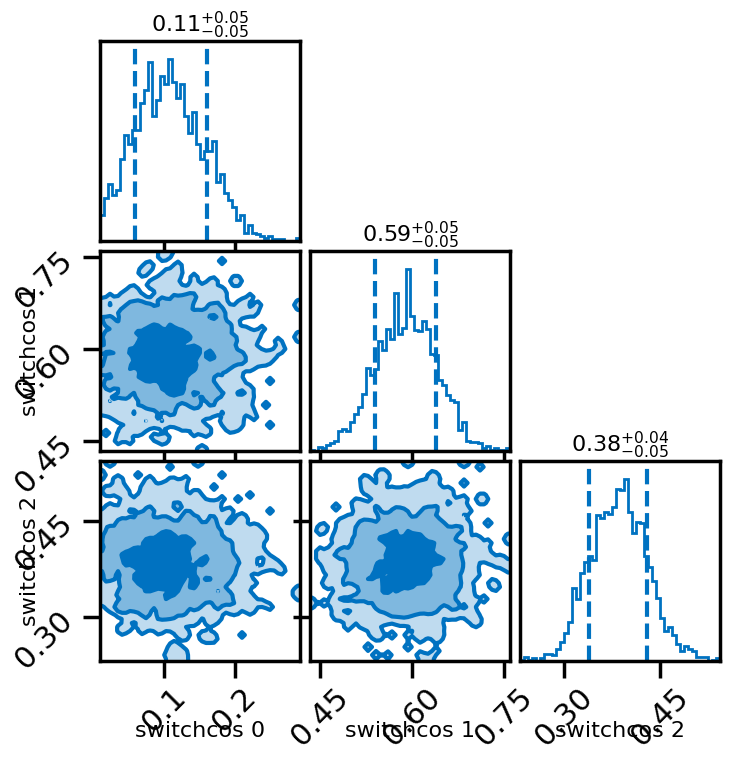

In [13]:
# Posterior of the mixing parameters. 
result.plot_corner()

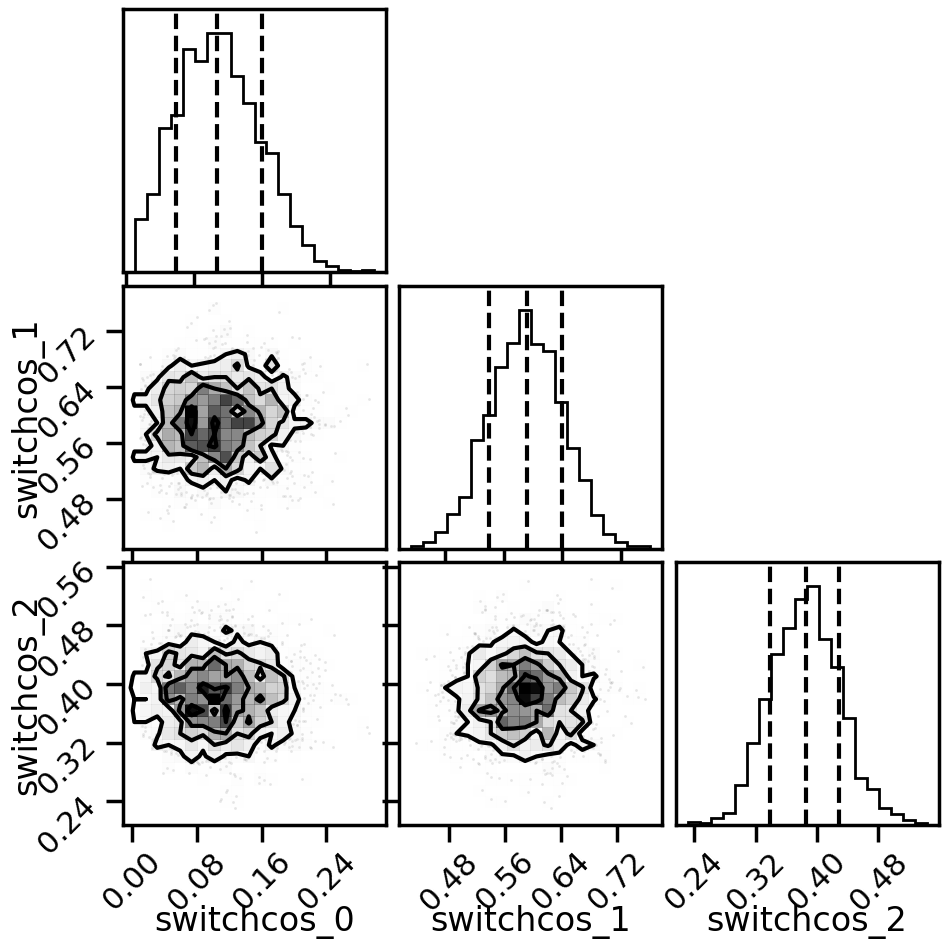

In [14]:
#corner plots
import corner
fig, axs = plt.subplots(3,3, figsize=(10,10), dpi=100)
corner.corner(mix_model.posterior,labels=['switchcos_0','switchcos_1', 'switchcos_2'],quantiles=[0.16, 0.5, 0.84],fig=fig)
plt.show()

## 4. Predictions

In [15]:
_,mean_prior,CI_prior, _ = mix_model.prior_predict(plot_g, CI=[5,20,80,95])
_,mean,CI, _ = mix_model.predict(plot_g, CI=[5,20,80,95])

(10000, 3)
using provided samples instead of posterior


In [16]:
mean.shape

(1, 100)

In [17]:
per5, per20, per80, per95 = CI
prior5, prior20, prior80, prior95 = CI_prior

In [18]:
# Map value prediction for the step mixing function parameter
map_prediction = mix_model.evaluate(mix_model.map, plot_g)

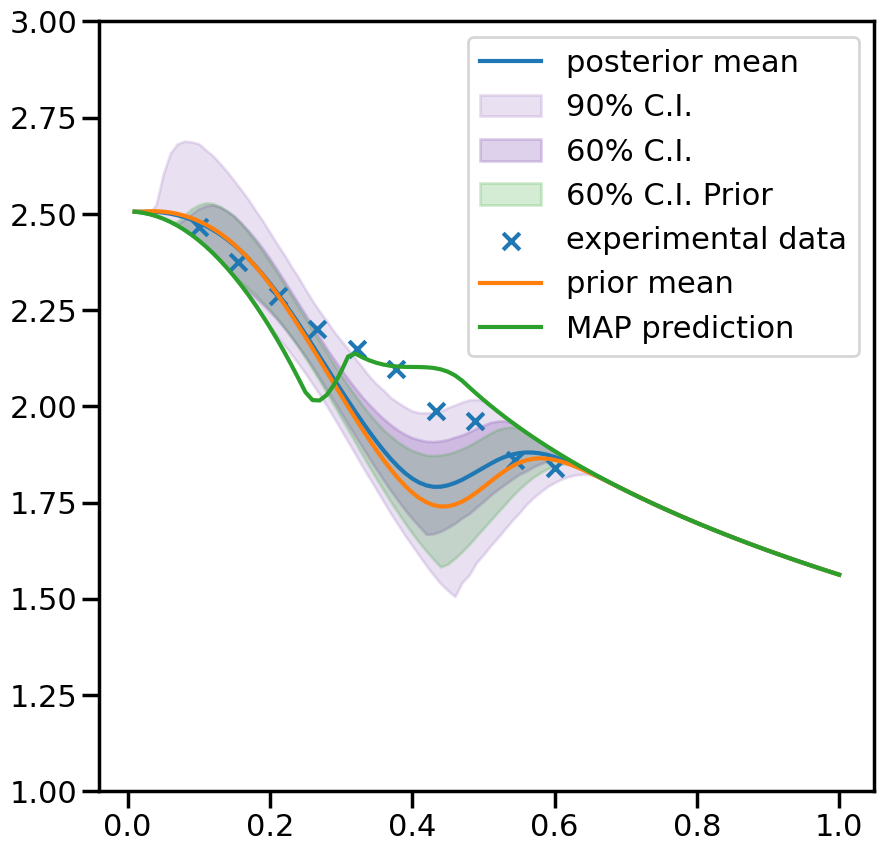

In [19]:
%matplotlib inline
sns.set_context('poster')
fig, ax = plt.subplots(figsize=(10,10))
ax.plot(plot_g, mean.flatten(), label='posterior mean')
ax.fill_between(plot_g,per5.flatten(),per95.flatten(),color=sns.color_palette()[4], alpha=0.2, label='90% C.I.')
ax.fill_between(plot_g,per20.flatten(),per80.flatten(), color=sns.color_palette()[4], alpha=0.3, label='60% C.I.')
ax.fill_between(plot_g,prior20.flatten(),prior80.flatten(),color=sns.color_palette()[2], alpha=0.2, label='60% C.I. Prior')
ax.scatter(g,exp_data[0], marker='x', label='experimental data')
ax.plot(plot_g, mean_prior.flatten(), label='prior mean')
ax.plot(plot_g, map_prediction.flatten(), label='MAP prediction')
ax.set_ybound(1,3)
ax.legend()